### Handwritten digits

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape) # 64 dimensions
print(digits.keys())
print(digits.data.shape)
print(digits.images[0])
print(digits.data[0])
print(digits.target)
print(digits.target[0])

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


### Tasks. Part 1. Unsupervised Learning: Dimensionality Reduction on Digits

We'd like to visualize our points within the 64-dimensional parameter space, but it's difficult to plot points in $N=64$ dimensions! So we need to reduce the dimensionality of the space

3) Use the unsupervised dimensionality reduction technique called **[`Isomap`](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html#sklearn.manifold.Isomap)**. Isomap is an embedding tecnique, which tries to understand if your $N$ dimensional datapoint live in a $M$ dimensional (with $M<N$) manyfold. Reduce the MINST dataset.  Do some plots to visualize your results 

In [27]:
X, y = digits.data, digits.target

iso = Isomap(n_components=2)
iso.fit(X)
X_reduced = iso.transform(X)
print(X_reduced.shape)

c:\Users\aless\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:352: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\aless\anaconda3\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


(1797, 2)


Text(0.5, 1.0, 'True labels')

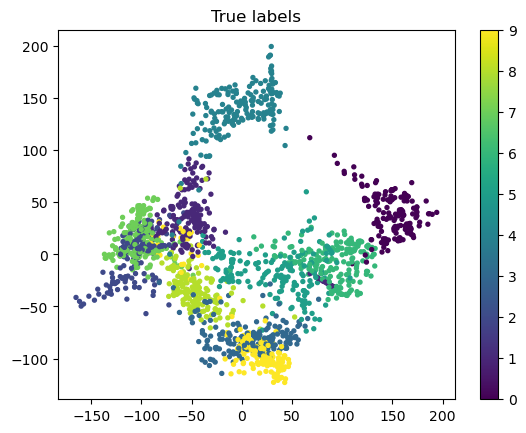

In [46]:
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=digits.target, s=8)
plt.colorbar()
plt.title(label='True labels')

### Tasks. Part 2. Supervised Learning: Classification on Digits

Now we want to classify the dataset. 

4) Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set. You need `sklearn.model_selection.train_test_split`.

5) Use a simple [`Logistic Regression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) which despite its name is a common classification algorithm. (I know, this is confusing!). Use the flag `solver='sag'` (I found the default solver had a bug, at least when I tried).

6) Compute the accuracy (`sklearn.metrics.accuracy_score`) of your emulator. In this context, accuracy is simply the fraction of the digits that were correctly identified. Compute the accuracy on both the training and the validation set. Comment on the results.

7) The accuracy is a single number doesn't tell us ***where*** we've gone wrong. Plot the ***confusion matrix*** as we did above. What are the digits that are more challenging to identify, does it make sense?

In [70]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_reduced, y, test_size=0.2, train_size=0.8, random_state=42)

clf = LogisticRegression(solver='sag')
clf.fit(Xtrain, ytrain)
ytrain_pred = clf.predict(Xtrain)
ytest_pred = clf.predict(Xtest)


acc_train = accuracy_score(ytrain, ytrain_pred)
acc_test = accuracy_score(ytest, ytest_pred)
print(f"Training accuracy: {acc_train:.3f}")
print(f"Test accuracy: {acc_test:.3f}")

Training accuracy: 0.617
Test accuracy: 0.628


c:\Users\aless\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


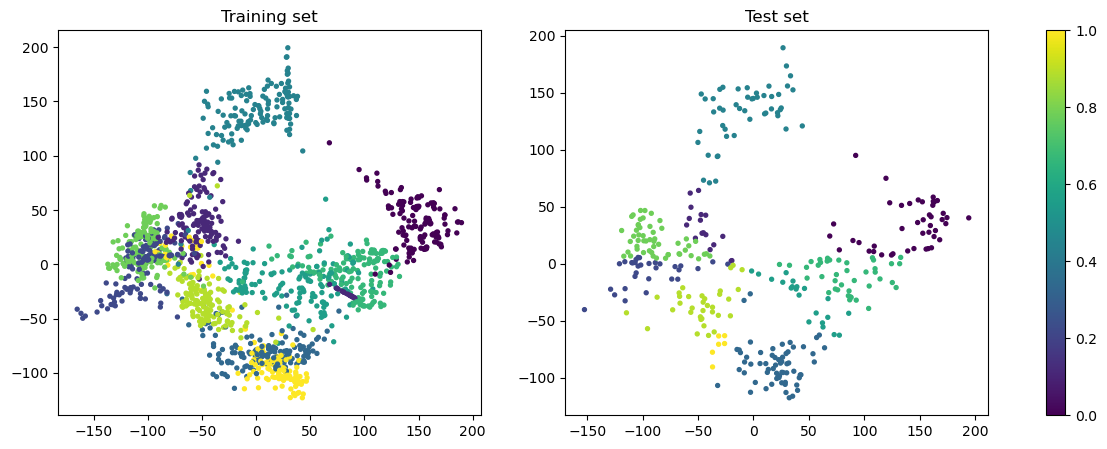

In [71]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(Xtrain[:,0], Xtrain[:,1], c=ytrain, s=8)
ax[0].set_title('Training set')
ax[1].scatter(Xtest[:,0], Xtest[:,1], c=y_pred, s=8)
ax[1].set_title('Test set')
fig.colorbar(mappable=plt.cm.ScalarMappable(), ax=ax, orientation='vertical')

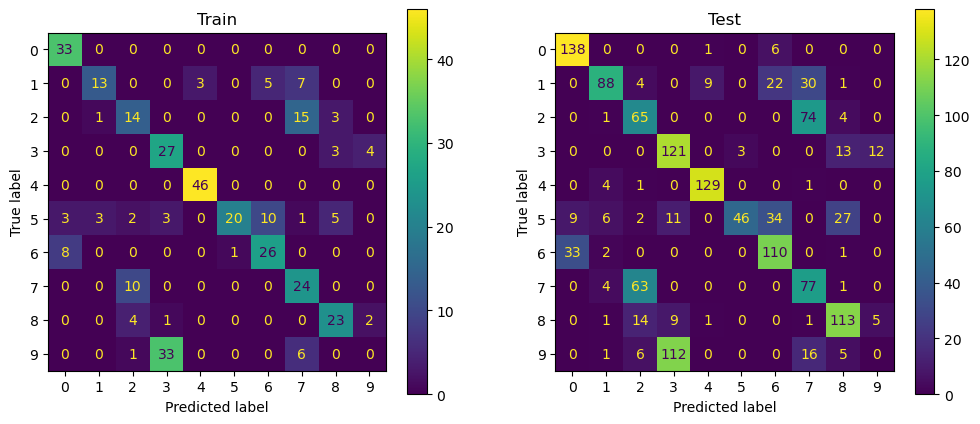

In [75]:
conf_matr_train = confusion_matrix(ytrain, ytrain_pred)
conf_matr_test = confusion_matrix(ytest, ytest_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=conf_matr_train, display_labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
disp_test = ConfusionMatrixDisplay(confusion_matrix=conf_matr_test, display_labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].set_title("Train")
ax[1].set_title("Test")

disp_test.plot(ax=ax[0])
disp_train.plot(ax=ax[1])